In [ ]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime as dt

from piepy.core.data_functions import make_subsets
from piepy.psychophysics.wheel.detection.wheelDetectionExperimentHub import WheelDetectionExperimentHub
from piepy.plotters.psychophysics.detection.delta_effect_plot import plot_delta_effect_contrast, plot_delta_effect_areas

In [ ]:
DATA_PATH = Path.cwd().parents[0] / "260410_Ncomm_inhibition_data.parquet"

In [ ]:
hub = WheelDetectionExperimentHub()
# load from session list
# hub.set_data(all_sessions,
#              load_sessions=True,
#              make_summary=True)
# hub.data.write_parquet("250206_experiment_data.parquet")

# load from saved data
all_data = pl.read_parquet(DATA_PATH)
hub.set_data(all_data,
             load_sessions=True,
             make_summary=True)

animalid,area,stimulus_count,stim_combination,opto_targets,isTitrated,isCNO,total_trials,stim_type,experiment_count,date,session_ids,stat_total_trial_count,stat_early_trial_count,stat_stim_trial_count,stat_correct_trial_count,stat_miss_trial_count,stat_catch_trial_count,stat_opto_trial_count,stat_opto_ratio,stat_nonopto_hit_rate,stat_correct_rate,stat_hit_rate,stat_false_alarm_rate,stat_nogo_rate,stat_median_response_time,stat_median_reaction_time,stat_d_prime,stat_easy_trial_count,stat_easy_hit_rate,stat_easy_nogo_rate,stat_easy_median_response_time,stat_easy_median_reaction_time
str,str,i32,str,i32,bool,bool,u32,list[str],u32,list[date],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[f64],list[f64],list[f64],list[f64]
"""KC139""","""AL""",1,"""0.04cpd_8.0Hz""",1,false,false,341,"[""0.04cpd_8.0Hz""]",1,[2022-10-18],[5216356],[341],[106],[213],[134],[79],[22],[80],[23.46],[69.925],[39.296],[62.911],[31.085],[37.089],[282.0],[177.6],[0.82294],[69],[98.551],[1.449],[266.0],[166.1]
"""KC139""","""AM""",1,"""0.04cpd_8.0Hz""",1,false,false,327,"[""0.04cpd_8.0Hz""]",1,[2022-11-08],[4297397],[327],[99],[213],[129],[84],[15],[79],[24.159],[66.418],[39.45],[60.563],[30.275],[39.437],[300.0],[178.6],[0.784455],[65],[90.769],[9.231],[282.0],[163.6]
"""KC139""","""LM""",1,"""0.04cpd_8.0Hz""",1,false,false,849,"[""0.04cpd_8.0Hz""]",1,[2022-11-01],[6503303],[849],[267],[536],[445],[91],[46],[177],[20.848],[95.822],[52.415],[83.022],[31.449],[16.978],[282.0],[171.3],[1.438198],[187],[98.93],[1.07],[249.0],[147.0]
"""KC139""","""PM""",1,"""0.04cpd_8.0Hz""",1,false,false,836,"[""0.04cpd_8.0Hz""]",1,[2022-11-16],[2940665],[836],[331],[463],[369],[94],[42],[155],[18.541],[86.039],[44.139],[79.698],[39.593],[20.302],[299.0],[196.2],[1.094779],[142],[100.0],[0.0],[265.0],[163.8]
"""KC139""","""RL""",1,"""0.04cpd_8.0Hz""",1,false,false,342,"[""0.04cpd_8.0Hz""]",1,[2022-10-25],[3884121],[342],[162],[164],[109],[55],[16],[54],[15.789],[70.909],[31.871],[66.463],[47.368],[33.537],[300.0],[187.9],[0.491155],[50],[96.0],[4.0],[282.0],[171.9]
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KC152""","""V1retino""",1,"""0.04cpd_8.0Hz""",2,false,false,512,"[""0.04cpd_8.0Hz""]",1,[2024-08-26],[4243291],[512],[92],[380],[134],[246],[40],[117],[22.852],[41.445],[26.172],[35.263],[17.969],[64.737],[366.0],[251.6],[0.538317],[135],[61.481],[38.519],[350.0],[224.8]
"""KC152""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,674,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2024-08-18],[4233727],[674],[192],[433],[248],[185],[49],[134],[19.881],[71.237],[36.795],[57.275],[28.487],[42.725],[333.0],[215.6],[0.751814],[151],[92.715],[7.285],[283.0],[182.9]
"""KC152""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,true,550,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2024-08-19],[9727223],[550],[71],[428],[155],[273],[51],[157],[28.545],[52.03],[28.182],[36.215],[12.909],[63.785],[366.0],[256.2],[0.777985],[155],[72.258],[27.742],[349.5],[233.6]


In [3]:
df = hub.filter_by_animals(['KC139','KC142','KC143',
                            'KC144','KC145','KC146',
                            'KC147','KC148','KC149',
                            'KC150','KC151','KC152'],
                      stim_combination="0.04cpd_8.0Hz",
                      isCNO=False)

valid_sesh_ids = []
for filt_tup in make_subsets(df,["session_id"]):
    filt_df = filt_tup[-1]
    if 1.0 not in filt_df["contrast"].to_list() and 0.0625 not in filt_df["contrast"].to_list():
        print(filt_tup[0],filt_df["contrast"].unique().to_list())
        print(filt_df.filter(pl.col("session_id")==filt_tup[0])[0,"session_path"])
        valid_sesh_ids.append(filt_tup[0]) 
    else:
        pass
    
df.filter(pl.col("session_id").is_in(valid_sesh_ids))

KC139_V1retino doesn't have a session with hit rate >=75 and stim_trial_count>=300, removing...
KC142_PM doesn't have a session with hit rate >=75 and stim_trial_count>=300, removing...
KC142_ventralPM doesn't have a session with hit rate >=75 and stim_trial_count>=300, removing...
KC142_ventralPM doesn't have a session with hit rate >=75 and stim_trial_count>=300, removing...
KC148_AL doesn't have a session with hit rate >=75 and stim_trial_count>=300, removing...
67485 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230112_KC143_detect_opto120_dorsal__no_cam_KC
575064 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/240404_KC147_detect_opto120_ALRLvsSomato__no_cam_KC
702469 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230117_KC144_detect_opto120_AL__no_cam_KC
818473 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230607_KC146_detect_opto120_ventralPM__no_cam_KC
831652 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/221018_KC142_detect_opto120_dorsal__n

total_trial_no,trial_no,t_trialstart,t_trialend,reward,lick,t_vstimstart_rig,t_vstimend_rig,t_vstimstart,t_vstimend,vstim_time_diff,state_time_diff,outcome,wheel_t,wheel_pos,reaction_time,peak_speed,isCatch,t_trialinit,duration_quiescence,duration_blank,state_outcome,state_response_time,iTrial,prob,opto,opto_pattern,total_iStim,corrected_presentTime,contrast,sf,tf,stim_pos,median_loop_time,rig_response_tick,rig_response_time,opto_pulse,…,stat_early_trial_count,stat_stim_trial_count,stat_correct_trial_count,stat_miss_trial_count,stat_catch_trial_count,stat_opto_trial_count,stat_opto_ratio,stat_nonopto_hit_rate,stat_correct_rate,stat_hit_rate,stat_false_alarm_rate,stat_nogo_rate,stat_median_response_time,stat_median_reaction_time,stat_d_prime,stat_easy_trial_count,stat_easy_hit_rate,stat_easy_nogo_rate,stat_easy_median_response_time,stat_easy_median_reaction_time,opto_ratio,opto_targets,stimulus_count,stim_combination,isTitrated,rig,session_id,session_path,user,opto_power,imaging,paradigm,area,isCNO,contrast_vector,sf_values,tf_values
i64,u64,u64,u64,list[f64],list[f64],u64,u64,u64,u64,f64,f64,str,list[f64],list[i64],f64,f64,bool,f64,f64,f64,i64,f64,i64,f64,bool,i64,i64,list[f64],f64,f64,f64,i64,f64,i64,f64,list[f64],…,i32,i32,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,i32,i32,str,bool,str,i32,str,str,str,str,str,str,bool,list[f64],list[f64],list[f64]
923,1,2079,8495,[],[],null,null,null,null,0.0,0.0,"""early""","[2094.0, 2162.0, … 8102.0]","[-1423, -1424, … -1344]",-311.0,7.397647,false,2813.0,733.0,1407.0,-1,-255.0,null,null,false,-1,null,[],null,null,null,null,null,null,null,[],…,171,210,127,83,15,77,19.444,75.94,32.071,60.476,43.182,39.524,299.0,201.2,0.43743,58,98.276,1.724,265.0,164.4,0.3,1,1,"""0.04cpd_8.0Hz""",false,"""rig3""",9718279,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""dorsal""",false,"[0.5, 0.125, 0.0]",[0.04],[8.0]
924,2,8536,11169,"[10616.0, 41.0]","[10711.0, 10817.0, … 11091.0]",10285,10659,10285,10652,-29.418,-40.0,"""hit""","[9674.0, 10462.0, … 11128.0]","[-1343, -1342, … -789]",178.0,12.827252,false,8819.0,282.0,1464.0,1,249.0,2,0.1575,false,-1,2,"[10285.0, 10302.018, … 10651.661]",0.5,0.04,8.0,37,16.661,null,null,[],…,171,210,127,83,15,77,19.444,75.94,32.071,60.476,43.182,39.524,299.0,201.2,0.43743,58,98.276,1.724,265.0,164.4,0.3,1,1,"""0.04cpd_8.0Hz""",false,"""rig3""",9718279,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""dorsal""",false,"[0.5, 0.125, 0.0]",[0.04],[8.0]
925,3,11168,21702,[],"[11195.0, 11301.0, … 18183.0]",16168,17176,16168,21185,-28.984,-39.0,"""miss""","[11135.0, 11144.0, … 21363.0]","[-793, -797, … -28]",null,null,false,13285.0,2115.0,2867.0,0,1000.0,3,0.135,true,0,3,"[16168.0, 16184.809, … 17168.038]",0.125,0.04,8.0,37,16.676,null,null,[16168.0],…,171,210,127,83,15,77,19.444,75.94,32.071,60.476,43.182,39.524,299.0,201.2,0.43743,58,98.276,1.724,265.0,164.4,0.3,1,1,"""0.04cpd_8.0Hz""",false,"""rig3""",9718279,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""dorsal""",false,"[0.5, 0.125, 0.0]",[0.04],[8.0]
926,4,21663,27396,[],[23232.0],null,null,null,null,0.0,0.0,"""early""","[22815.0, 22825.0, … 26319.0]","[-26, -24, … 281]",-86.2,8.868781,false,22162.0,499.0,740.0,-1,-23.0,null,null,false,-1,null,[],null,null,null,null,null,null,null,[],…,171,210,127,83,15,77,19.444,75.94,32.071,60.476,43.182,39.524,299.0,201.2,0.43743,58,98.276,1.724,265.0,164.4,0.3,1,1,"""0.04cpd_8.0Hz""",false,"""rig3""",9718279,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""dorsal""",false,"[0.5, 0.125, 0.0]",[0.04],[8.0]
927,5,27435,30635,"[30083.0, 41.0]","[30155.0, 30258.0, … 30545.0]",29618,30126,29618,30119,-28.618,-39.0,"""hit""","[28022.0, 28118.0, … 30593.0]","[282, 282, … 601]",290.6,8.920348,false,27852.0,416.0,1756.0,1,383.0,5,0.135,true,0,5,"[29618.0, 29635.086, … 30118.01]",0.5,0.04,8.0,37,16.627,null,null,[29618.0],…,171,210,127,83,15,77,19.444,75.94,32.0

In [ ]:
a = df.group_by(["area"]).agg(pl.col("animalid").unique()).sort("area")
a

In [ ]:
a.filter(pl.col("area")=="HVA")[0,"animalid"].sort().explode().to_list()

 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['hit', 'miss', 'early']


/Users/kaan/miniconda3/envs/piepy/lib/python3.10/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/kaan/code/piepy/piepy/core/statistics.py:54: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  res = bootstrap(


p1= nan, data doesn't appear to normal, doing wilcoxon test
LM WilcoxonResult(statistic=15.0, pvalue=0.7421875)
AL WilcoxonResult(statistic=6.0, pvalue=0.09289194088370531)
RL WilcoxonResult(statistic=5.0, pvalue=0.0390625)
PM WilcoxonResult(statistic=5.0, pvalue=0.15625)
AM WilcoxonResult(statistic=8.0, pvalue=0.6001794871405538)
holm-bonferonni corrected p-values
0.7421875
0.09289194088370531
0.0390625
0.15625
0.6001794871405538
LM-AL: WilcoxonResult(statistic=16.0, pvalue=0.84375)
LM-RL: WilcoxonResult(statistic=9.0, pvalue=0.25)
LM-PM: WilcoxonResult(statistic=14.0, pvalue=1.0)
LM-AM: WilcoxonResult(statistic=12.0, pvalue=0.8125)
AL-RL: WilcoxonResult(statistic=6.0, pvalue=0.109375)
AL-PM: WilcoxonResult(statistic=11.0, pvalue=0.6875)
AL-AM: WilcoxonResult(statistic=12.0, pvalue=0.8125)
RL-PM: WilcoxonResult(statistic=5.0, pvalue=0.15625)
RL-AM: WilcoxonResult(statistic=5.0, pvalue=0.15625)
PM-AM: WilcoxonResult(statistic=14.0, pvalue=1.0)
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


/Users/kaan/miniconda3/envs/piepy/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/Users/kaan/code/piepy/piepy/plotters/psychophysics/detection/delta_effect_plot.py:1071: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


[0 1 2 3 4]
[ 1.26180746  2.48361668 14.83787277  3.37236918  0.69579378]
[7.18858338 1.64357148 6.1295311  2.39771947 1.56297828]


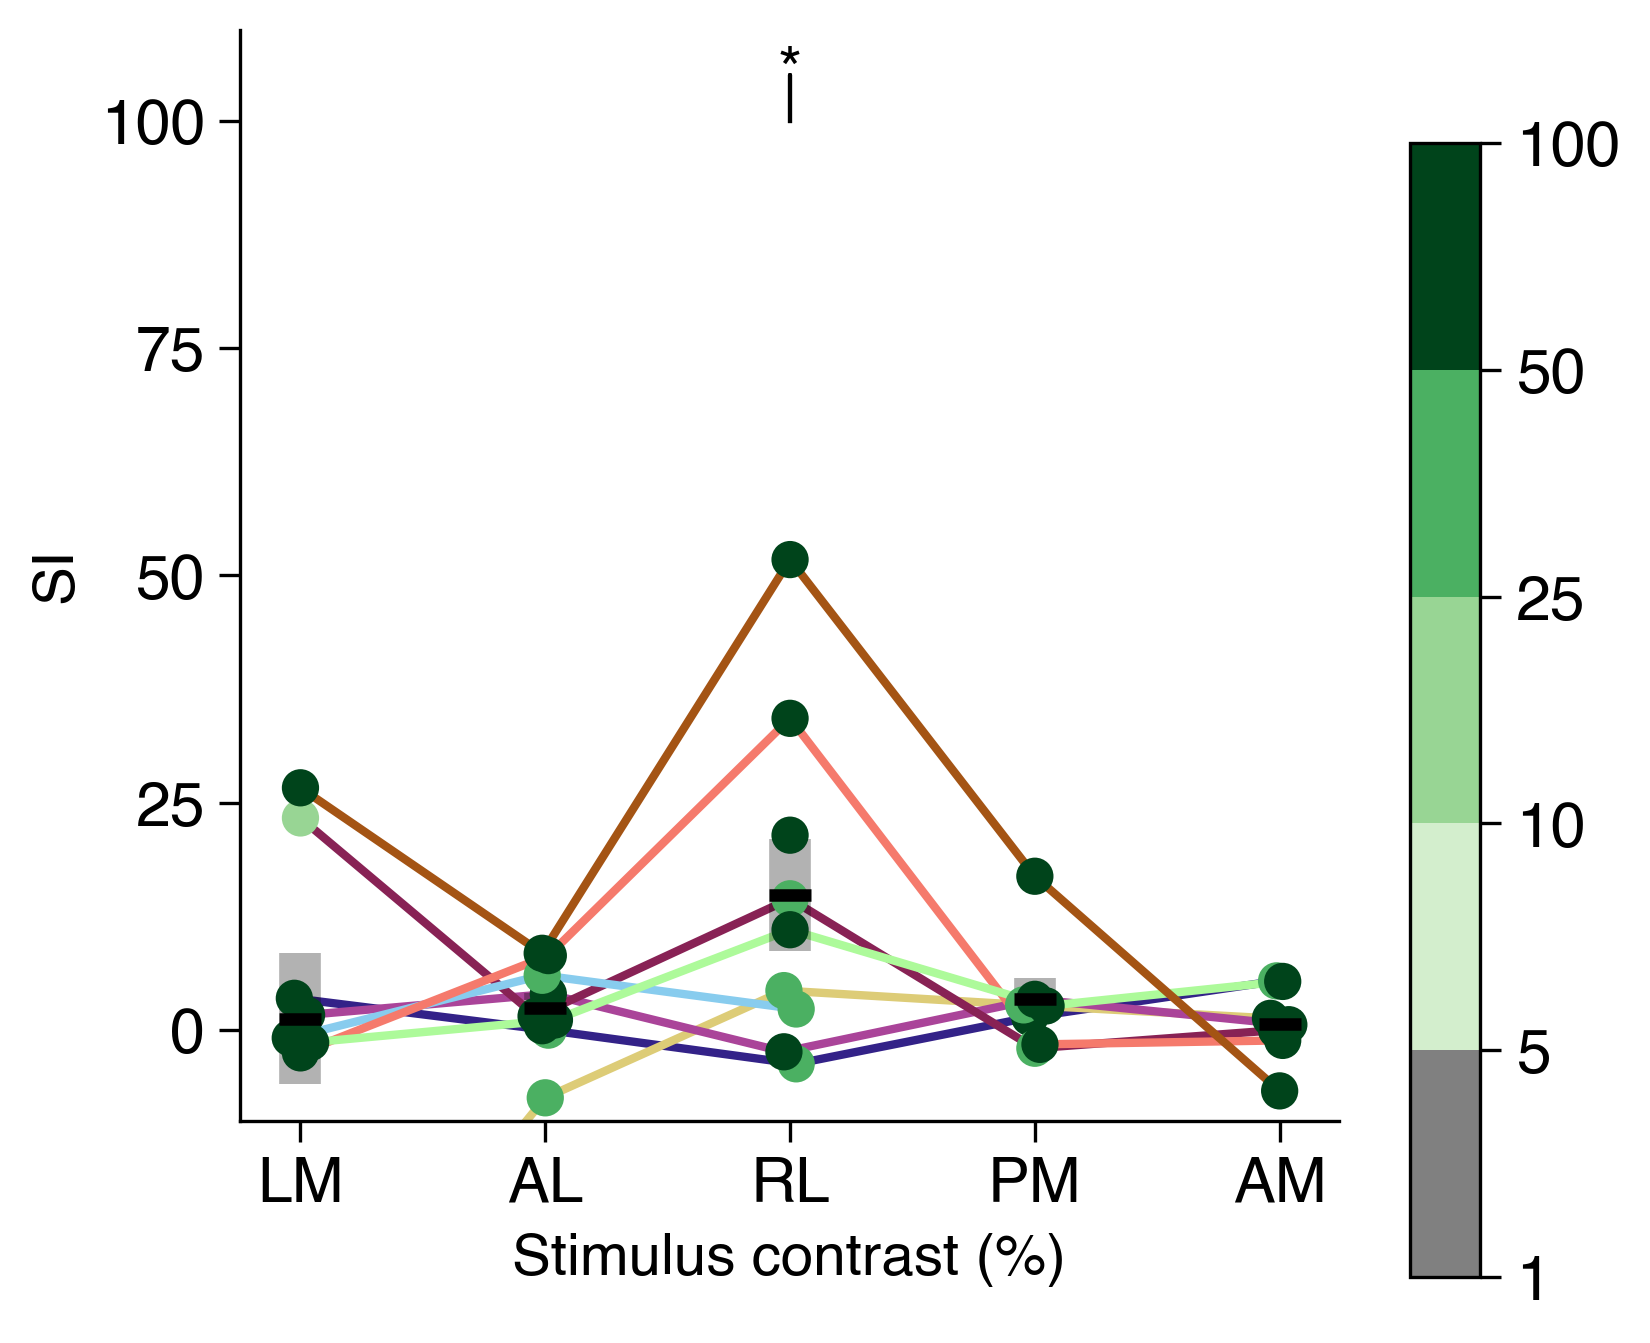

In [4]:
cm = 1/2.54
contrast = 0.5
effect_on = "hit_rate"
f,ax = plot_delta_effect_areas(data=df,
                               effect_on=effect_on,
                               effect_metric="BSI",
                               plot_with="sem",
                               contrast=contrast,
                               areas = ["LM","AL","RL","PM","AM"],
                               polarity=1,
                               trial_count_identifier="dot_color",
                               trial_bounds=(1,5,10,25,50,100),
                               dot_cmap="Greens",
                               mpl_kwargs={"figsize":(12*cm,12*cm),
                                           "linewidths":0,
                                           "s":80},
                               style="print")

In [ ]:
savename = f"{dt.strftime(dt.today(),'%y%m%d')}_{contrast}_ALLAREAS_delta_hit_rate.pdf"
f.savefig(f"pdf/{savename}.pdf")
f.savefig(f"svg/{savename}.svg")